<a href="https://colab.research.google.com/github/Anushakadira/Anu/blob/main/Data_science_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
#Import Libraries

In [10]:
1.# To Handle the Data
import numpy as np
import pandas as pd
2.# To Visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [11]:
## DATA PREPROCESSING

In [12]:
3.#To Preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer,KNNImputer



In [13]:
4.#import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [14]:
5.#To train the model in ML
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score

In [15]:
6.#For classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# to save the model
import pickle

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [16]:
## Load the Dataset

In [17]:
#way-1: load the data from csv placed locally in our pc
df = pd.read_csv('heart_disease_uci.csv')
#displaying top 5 rows of data
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [18]:
### EXPLORATORY DATA ANALYSIS
#Preview the data
#explore each column's datatypes and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [19]:
#check the shape of dataset
df.shape

(920, 16)

In [20]:
df.loc[:,["age","trestbps","chol","thalch"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.51,9.42,28.0,47.0,54.0,60.0,77.0
trestbps,861.0,132.13,19.07,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.13,110.78,0.0,175.0,223.0,268.0,603.0
thalch,865.0,137.55,25.93,60.0,120.0,140.0,157.0,202.0


In [21]:
## Explore each column
#id
#find min and max value of id variable
df['id'].min(), df['id'].max()

(1, 920)

In [22]:
#is there any id number duplicate?
df['id'].nunique()
#Answer: No, there are unique id number in each row.

920

In [23]:
#age
#summary statistics of 'age' variable
df['age'].describe()

,age
count,920.000000
mean,53.510870
std,9.424685
min,28.000000
25%,47.000000
50%,54.000000
75%,60.000000
max,77.000000


Mean:  53.51086956521739
Mode:  54
Median:  54.0


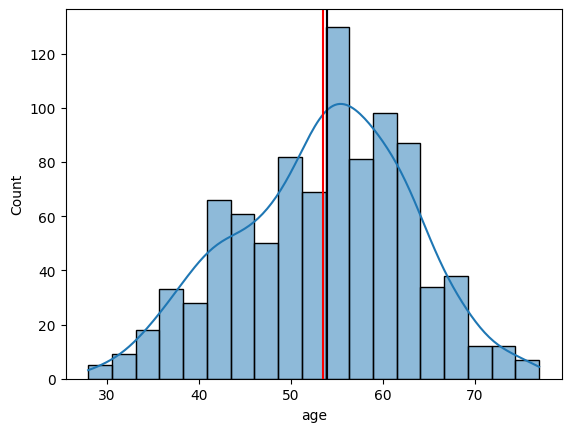

In [24]:
# Check mean,median and mode of age column
Mean = df['age'].mean()
Mode = df['age'].mode()[0]
Median = df['age'].median()
sns.histplot(df['age'],kde=True)
plt.axvline(df['age'].mean(),color='red')
plt.axvline(df['age'].mode()[0],color='blue')
plt.axvline(df['age'].median(),color='black')

print('Mean: ', Mean)
print('Mode: ', Mode)
print('Median: ', Median)

Mean:  53.51086956521739
Mode:  54
Median:  54.0

**Observation**:

22 Females are in the range of 54 - 55.
70 Males are in the range of 54 - 55.
So according to this dataset , Males are getting heart disease more than females

In [25]:
#minimum and maximum age for heart disease
print("The minimum age for heart disease diagnosis is: ",df['age'].min())
print("The maximum age for heart disease diagnosis is: ",df['age'].max())

The minimum age for heart disease diagnosis is:  28
The maximum age for heart disease diagnosis is:  77


✅ Age column found, proceeding with analysis...


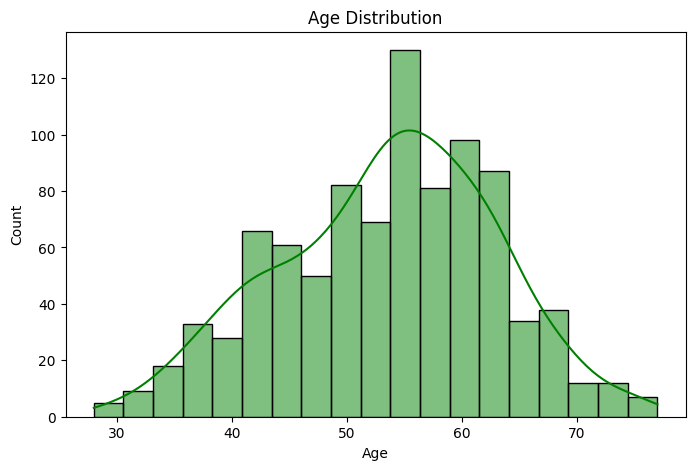

✅ 'sex' column found, proceeding with gender-based analysis...


,count
sex,
Male,726
Female,194


In [26]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Load dataset (Ensure the file path is correct)
df = pd.read_csv("heart_disease_uci.csv")

# Clean column names to avoid KeyErrors (strip spaces & convert to lowercase)
df.columns = df.columns.str.strip().str.lower()

# Verify if 'age' column exists
if 'age' in df.columns:
    print("✅ Age column found, proceeding with analysis...")

    # Ensure 'age' is numeric
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

    # Drop NaN values from 'age'
    df = df.dropna(subset=['age'])

    # Plot Age Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='age', kde=True, color='green')
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.show()
else:
    print("❌ Error: 'age' column is missing! Check dataset structure.")

# ✅ Check if 'sex' column exists before plotting gender-based age distribution
if 'sex' in df.columns:
    print("✅ 'sex' column found, proceeding with gender-based analysis...")

    # Convert 'sex' to string (ensures smooth plotting)
    df['sex'] = df['sex'].astype(str)

    # Plot age distribution by gender
    fig = px.histogram(data_frame=df, x='age', color='sex', title="Age Distribution by Gender")
    fig.show()
else:
    print("❌ Error: 'sex' column is missing! Cannot analyze gender-based age distribution.")


#Sex
#lets check the value count of sex variable in this data
df['sex'].value_counts()

#males are in greater amount than females

In [27]:
#calculate the percentage of male & female value counts in data
male_count = 726
female_count = 194
total_count = male_count + female_count
#total count=920
#male percentage
male_percentage = (male_count/total_count) * 100
print("The percentage of male's value count in data is:", round(male_percentage,2),'%')
#female percentage
female_percentage = (female_count/total_count) * 100
print("The percentage of female's value count in data is:", round(female_percentage,2),'%')

The percentage of male's value count in data is: 78.91 %
The percentage of female's value count in data is: 21.09 %


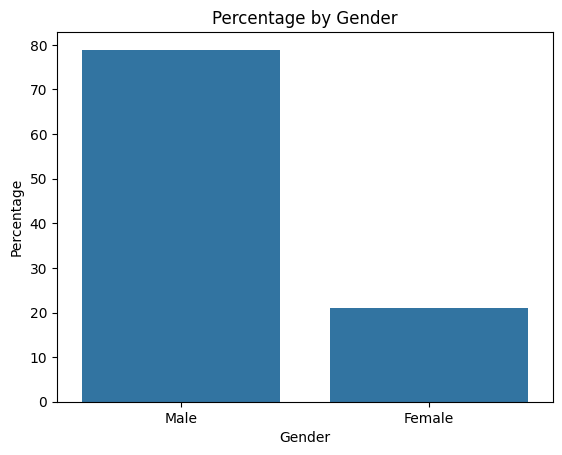

In [28]:
#plot percentages through barplot
sns.barplot(x=['Male', 'Female'], y=[male_percentage, female_percentage])
plt.title('Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.show()

**Observations**:

Males are 726 , Females are 194.
Percentage of Males in this dataset are 78.91.
Percentage of Females in this dataset are 21.08.
Males are 274% more in this dataset than Females.

In [113]:
#Dataset
#lets deal with 'dataset' variable
#find places where this data is collected
# Lets deal with dataset Column
df['dataset'].unique()


array(['train', 'test'], dtype=object)

In [114]:
df['dataset'].value_counts()

,count
dataset,
train,3
test,2


In [116]:
# make piechat of dataset column
fig = px.sunburst(df,path=['dataset','sex'])
fig.show()

**Observations**

These are the numbers of people from 4 different places

🌍 Location	Total
🌆 Cleveland	304
🇭🇺 Hungary	293
🌴 VA Long Beach	200
🇨🇭 Switzerland	123

<Axes: xlabel='dataset', ylabel='count'>

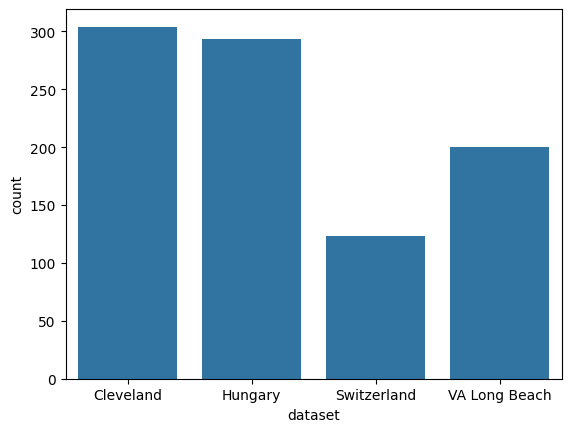

In [30]:
#plot the countplot of dataset variable
sns.countplot(data=df,x='dataset')

In [31]:
#lets find the sex ratio through groupby method in places where data is collected
df.groupby('dataset')['sex'].value_counts()

dataset        sex   
Cleveland      Male      207
               Female     97
Hungary        Male      212
               Female     81
Switzerland    Male      113
               Female     10
VA Long Beach  Male      194
               Female      6
Name: count, dtype: int64

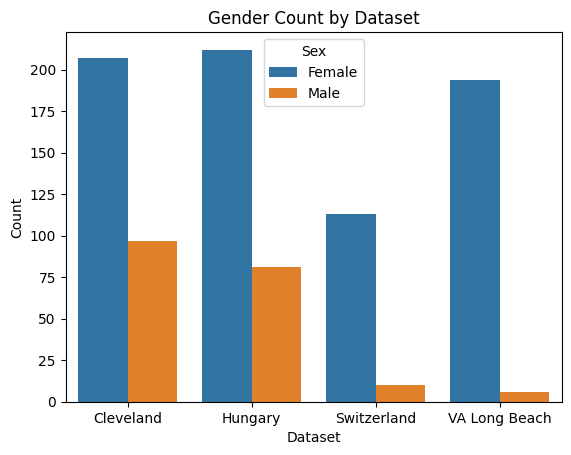

In [32]:
#plot this ratio
sns.countplot(data=df, x='dataset', hue='sex')
plt.title('Gender Count by Dataset')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend(title='Sex', labels=['Female', 'Male'])
plt.show()



*   The highest number of females belongs to cleveland=97,males belongs to Hungary = 212

*   The Lowest number of females belongs to VA LongBeach=6 and males belongs to Switzerland=113



In [33]:
# cp(Chest pain)
#let's find how many types are in cp variable

In [34]:
df['cp'].nunique()


4

In [35]:
#let's find what are those 4 types
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)



*   Typical Angina: Chest pain caused by reduced blood flow to the heart, usually triggered by physical exertion or stress
*   Asymptomatic: No noticeable chest pain or symptoms, even if there's underlying heart disease.

*   Non-Anginal: Chest pain not related to heart problems, often caused by conditions like acid reflux or muscle strain.
*   Atypical Angina: Chest pain with unusual symptoms, such as discomfort not directly linked to exertion or classic angina triggers.





In [36]:
#lets find value count of these types in data
df['cp'].value_counts()

,count
cp,
asymptomatic,496
non-anginal,204
atypical angina,174
typical angina,46


In [37]:
#In which age span, cp is on peak?
df.groupby('cp')['age'].value_counts().sort_values(ascending=False)

cp              age
asymptomatic    57     27
                58     23
                54     22
                59     22
                60     22
                       ..
non-anginal     35      1
                70      1
                73      1
typical angina  30      1
                74      1
Name: count, Length: 156, dtype: int64

In [38]:
#plot
fig = px.histogram(data_frame=df, x='age',color='cp')
fig.show()

<Axes: xlabel='cp', ylabel='count'>

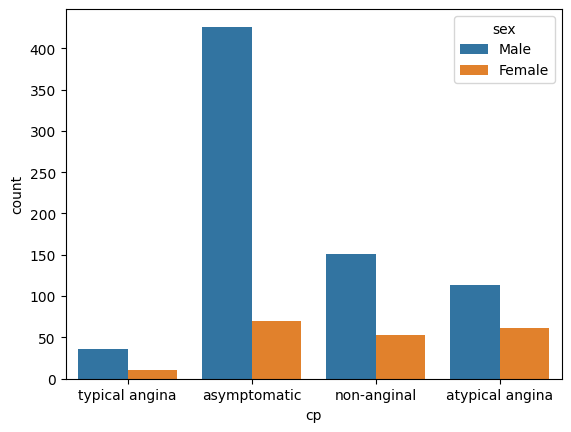

In [39]:
#countplot of cp column group by sex variable
sns.countplot(df, x='cp', hue='sex')



*   asymptomatic in males are larger compared to females. now the question is, in which dataset (place), asymptomatic data was maximum found.




<Axes: xlabel='cp', ylabel='count'>

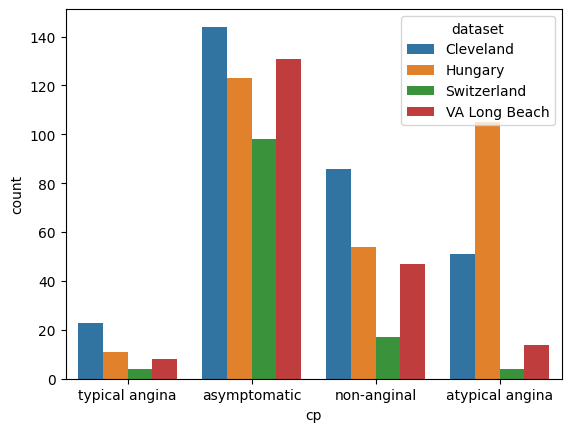

In [40]:
#countplot of cp column group by dataset variable
sns.countplot(df, x='cp', hue='dataset')

This graph shows that mostly data of asymptomatic collected from "Cleveland"

trestbps
(The normal resting blood pressure is 90/60 mm Hg & 120/80 mm Hg)

In [41]:
#preview the trestbps
df['trestbps'].head()

,trestbps
0,145.0
1,160.0
2,120.0
3,130.0
4,130.0


In [42]:
#summary statistics of trestbps
df['trestbps'].describe()

,trestbps
count,861.000000
mean,132.132404
std,19.066070
min,0.000000
25%,120.000000
50%,130.000000
75%,140.000000
max,200.000000


In [ ]:
df['trestbps'].min()

It is impossible to have a blood pressure at 0. So we are going to deal with this value and replacing it wiht null values.

<Axes: xlabel='trestbps', ylabel='Count'>

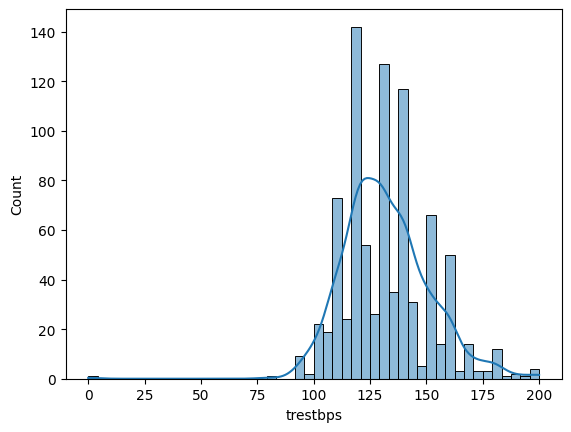

In [43]:
#create a histplot of trestbps column
sns.histplot(data=df, x='trestbps',kde=True)

**Observation**.

The Range of blood pressure is now between 80 - 200. Which is possible.

In [44]:
#missing values check
df['trestbps'].isnull().sum()

59

We have to impute these missing values in the next
steps.

In [45]:
#check trestbps value based on sex variable
(df.groupby('sex')['trestbps']).value_counts()

sex     trestbps
Female  120.0       32
        130.0       30
        140.0       18
        150.0       13
        110.0       11
                    ..
Male    123.0        1
        129.0        1
        164.0        1
        185.0        1
        192.0        1
Name: count, Length: 98, dtype: int64

In [46]:
#chol (cholestrol)
#cholestrol level = 0? is it outlier?
df['chol'].value_counts()
#Answer: 171 records consist of 0 cholestrol and dataset is collected from 4 different authentic places. So, these are not outliers.

,count
chol,
0.0,172
220.0,10
254.0,10
223.0,9
230.0,9
...,...
360.0,1
412.0,1
358.0,1


In [47]:
#fbs (fasting blood sugar)
df['fbs']


,fbs
0,True
1,False
2,False
3,False
4,False
...,...
915,True
916,False
917,True
918,True


In [48]:
df['restecg'].value_counts()


,count
restecg,
normal,551
lv hypertrophy,188
st-t abnormality,179


<Axes: xlabel='restecg', ylabel='count'>

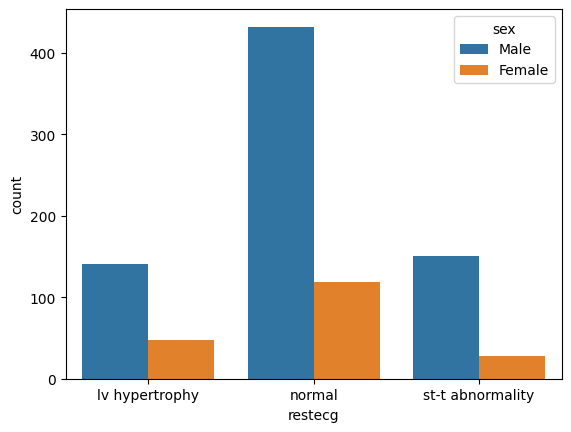

In [49]:
#restecg based on gender
df.groupby('sex')['restecg'].value_counts()
sns.countplot(data=df, x='restecg', hue='sex')

In [50]:
#thalch
print(df['thalch'].min()) #minimum
print(df['thalch'].max()) #maximum

60.0
202.0


In [51]:
# exang
df['exang']

,exang
0,False
1,True
2,True
3,False
4,False
...,...
915,False
916,NaN
917,False
918,NaN


In [52]:
#old peak
print(df['oldpeak'].min())
print(df['oldpeak'].max())

-2.6
6.2


In [53]:
#slope
df['slope'].value_counts()

,count
slope,
flat,345
upsloping,203
downsloping,63


* Flat: Indicates no significant change in the ST segment during exercise, often associated with a higher risk of heart disease.
* Upsloping: The ST segment rises during exercise, which is generally considered a normal response or less indicative of severe heart issues.
* Downsloping: The ST segment drops during exercise,
strongly associated with ischemia (insufficient blood flow to the heart) and heart disease risk.









The counts indicate how many patients in the dataset have each slope type, with flat slopes being the most common.

ca
In a heart disease dataset, ca typically refers to the number of major coronary arteries (0-3) that are colored by fluoroscopy. This variable is used to assess the extent of coronary artery disease (CAD).

Meaning of Values:
0: No major vessels are blocked or show significant narrowing. 1-3: Number of major coronary arteries (out of 3) that are narrowed or blocked. 1: One artery affected. 2: Two arteries affected. 3: Three arteries affected.

Significance: Higher values of ca indicate more severe coronary artery disease and a higher risk of heart-related complications





In [54]:
df['ca'].min()


0.0

In [55]:
df['ca'].max()

3.0

In [56]:
df['ca'].value_counts().head(4)

,count
ca,
0.0,181
1.0,67
2.0,41
3.0,20


In [57]:
df['thal'].value_counts()

,count
thal,
normal,196
reversable defect,192
fixed defect,46


In [58]:
#thal based on gender
df.groupby('sex')['thal'].value_counts()

sex     thal             
Female  normal                86
        reversable defect     21
        fixed defect           4
Male    reversable defect    171
        normal               110
        fixed defect          42
Name: count, dtype: int64

<Axes: xlabel='thal', ylabel='count'>

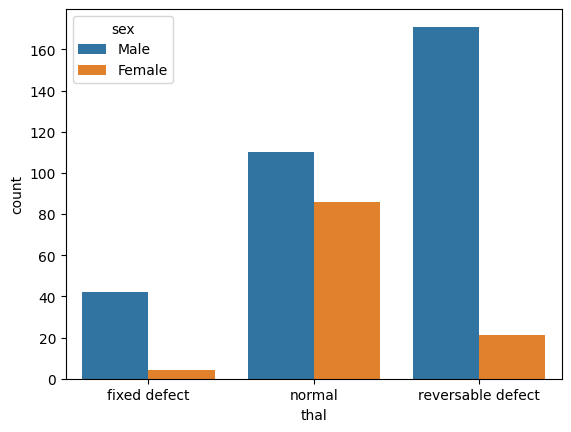

In [59]:
#plot
sns.countplot(data=df, x='thal', hue= 'sex')

num (target variable)
'num' typically refers to the diagnosis of heart disease, often represented as a categorical variable indicating the presence or absence of the condition.

Possible Values: 0: No heart disease (healthy). 1, 2, 3, 4: Different levels of heart disease severity, where higher values indicate more severe forms of the condition.

In [60]:
df['num'].describe()

,num
count,920.000000
mean,0.995652
std,1.142693
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4.000000


In [61]:
# Count of unique values in `num`
print(df['num'].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


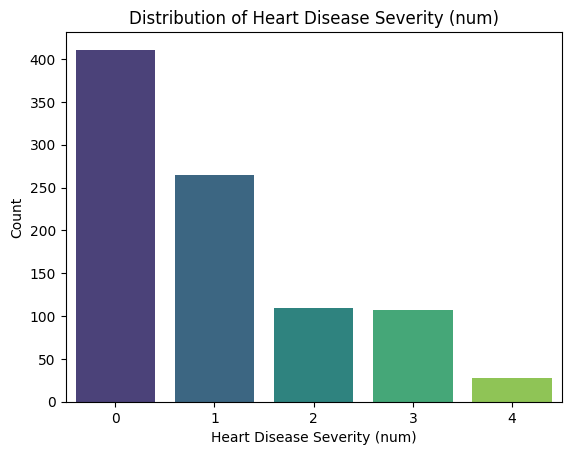

In [62]:
# Plot the distribution of `num` values
sns.countplot(data=df, x='num', palette='viridis')
plt.title('Distribution of Heart Disease Severity (num)')
plt.xlabel('Heart Disease Severity (num)')
plt.ylabel('Count')
plt.show()

In [63]:
# Percentage distribution of `num`
percentage_distribution = df['num'].value_counts(normalize=True) * 100
print(percentage_distribution)

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64


In [64]:
# Average age for each heart disease severity level
avg_age_per_num = df.groupby('num')['age'].mean()
print(avg_age_per_num)

num
0    50.547445
1    53.528302
2    57.577982
3    59.214953
4    59.214286
Name: age, dtype: float64


In [65]:
## Missing Values
#deal with missing values in trestbps column
print(f'The missing values in trestbps variable are: ',df['trestbps'].isnull().sum())

The missing values in trestbps variable are:  59


In [66]:
#percentage of missing values
print(f"The percentage of missing values in trestbps variable are: {df['trestbps'].isnull().sum()/len(df)*100:.2f}%")

The percentage of missing values in trestbps variable are: 6.41%


In [67]:
#impute missing values using iterative imputer
imputer = IterativeImputer(max_iter=10,random_state=42)
#fit the imputer on trestbps
imputer.fit(df[['trestbps']])
#transform
df['trestbps'] = imputer.transform(df[['trestbps']])

In [68]:
#verify if the missing values are imputed or not
df['trestbps'].isnull().sum()

0

In [69]:
#find only categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [70]:
#find only numeric columns
num_cols = df.select_dtypes(exclude='object').columns.tolist()
num_cols

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

In [71]:
#find only boolean columns
bool_cols = df.select_dtypes(include='bool').columns.tolist()
bool_cols

[]

In [72]:
(df.isnull().sum()/len(df) * 100).sort_values(ascending=False)

,0
ca,66.413043
thal,52.826087
slope,33.586957
fbs,9.782609
oldpeak,6.739130
thalch,5.978261
exang,5.978261
chol,3.260870
restecg,0.217391
id,0.000000


There are 9 columns which have missing values but
first we impute those column that has numerical datatype.

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [74]:
# [ca,oldpeak, thalch, chol]---> These are columns that has numeric dtype
#impute missing values by iterative imputer
imputer_1 = IterativeImputer(max_iter=10,random_state=42)
#fit_transform the imputer
df[['ca','oldpeak','thalch','chol']] = imputer_1.fit_transform(df[['ca','oldpeak','thalch','chol']])

In [75]:
#check if the missing values are imputed or not
(df.isnull().sum()/len(df) * 100).sort_values(ascending=False)

,0
thal,52.826087
slope,33.586957
fbs,9.782609
exang,5.978261
restecg,0.217391
id,0.000000
age,0.000000
sex,0.000000
dataset,0.000000
cp,0.000000


We have only 5 variables with missing values have object dtype.

In [76]:
##thal
df['thal'].value_counts()

,count
thal,
normal,196
reversable defect,192
fixed defect,46


<Axes: xlabel='thal', ylabel='count'>

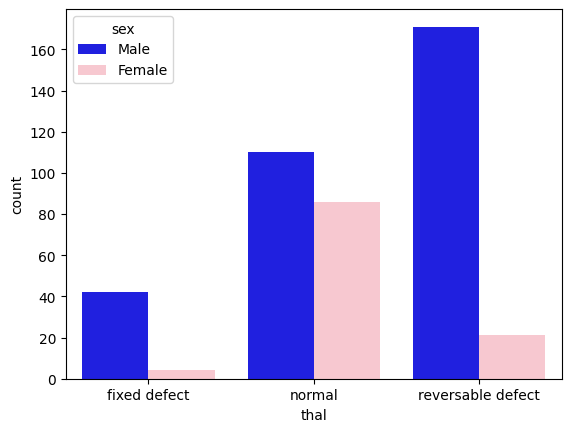

In [77]:
#plot 'thal' by sex variable
sns.countplot(data=df, x='thal', hue='sex', palette={'Male': 'blue', 'Female': 'pink'})

In [78]:
#missing value %age in 'thal' varibale
print(f"The percentage of missing values in this variable is: {df['thal'].isnull().sum()/len(df) *100:.2f}%")

The percentage of missing values in this variable is: 52.83%


In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

def impute_missing_values_with_rf(df, column_name):
    """
    Impute missing values in a categorical column using RandomForestClassifier.

    Parameters:
        df (pd.DataFrame): The input DataFrame with missing values.
        column_name (str): The name of the categorical column to impute.

    Returns:
        pd.DataFrame: The DataFrame with missing values imputed.
    """
    # Step 1: Create a copy of the original DataFrame to avoid modifying it directly
    df = df.copy()

    # Step 2: Check if the column has missing values
    if df[column_name].isnull().sum() == 0:
        print(f"No missing values in column '{column_name}' to impute.")
        return df

    print(f"Imputing missing values in column '{column_name}' with RandomForestClassifier...")

    # Step 3: Label encode the target column
    le = LabelEncoder()
    df[column_name] = df[column_name].astype(str)
    df[column_name] = df[column_name].apply(lambda x: np.nan if x.lower() == 'nan' else x)

    # Separate non-null and null data
    non_null_data = df[df[column_name].notnull()]
    null_data = df[df[column_name].isnull()]

    if null_data.empty:
        print(f"No missing values in '{column_name}' after preprocessing.")
        return df

    # Encode the target variable
    non_null_data[column_name] = le.fit_transform(non_null_data[column_name].astype(str))

    # Step 4: Define features (X) and target (y)
    X = non_null_data.drop(columns=[column_name])
    y = non_null_data[column_name]

    # One-hot encode the features
    X_encoded = pd.get_dummies(X, drop_first=True)

    # Align features for the null_data set
    null_data_encoded = pd.get_dummies(null_data.drop(columns=[column_name]), drop_first=True)
    null_data_encoded = null_data_encoded.reindex(columns=X_encoded.columns, fill_value=0)

    # Check for any data availability
    if null_data_encoded.empty:
        print("No matching features found between training data and null data for prediction.")
        return df

    # Step 5: Train RandomForestClassifier
    rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
    rf_model.fit(X_encoded, y)

    # Step 6: Predict missing values
    predicted_values = rf_model.predict(null_data_encoded)

    # Step 7: Decode the predicted values back to the original labels
    decoded_values = le.inverse_transform(predicted_values)

    # Step 8: Impute missing values in the original DataFrame
    df.loc[df[column_name].isnull(), column_name] = decoded_values

    print(f"Missing values in '{column_name}' have been imputed successfully.")
    return df


In [80]:
#impute missing values
import pandas as pd
import numpy as np

# Example DataFrame with missing values in the 'thal' column
data = {
    'thal': ['fixed', 'normal', None, 'reversible', 'normal', None],
    'age': [63, 45, 52, 57, 64, 48],
    'cp': [1, 4, 3, 2, 1, 2]
}
df = pd.DataFrame(data)


In [81]:
# Call the function to impute missing values in the 'thal' column
df = impute_missing_values_with_rf(df, 'thal')

# Check the result
print(df)


Imputing missing values in column 'thal' with RandomForestClassifier...
No missing values in 'thal' after preprocessing.
         thal  age  cp
0       fixed   63   1
1      normal   45   4
2        None   52   3
3  reversible   57   2
4      normal   64   1
5        None   48   2


In [82]:
# Example DataFrame
data = {
    'slope': [None, 'upsloping', 'flat', None, 'downsloping', 'flat'],
    'age': [63, 45, 52, 57, 64, 48],
    'cp': [1, 4, 3, 2, 1, 2]
}
df = pd.DataFrame(data)

# Impute missing values
df = impute_missing_values_with_rf(df, 'slope')

# Check results
print(df)

Imputing missing values in column 'slope' with RandomForestClassifier...
No missing values in 'slope' after preprocessing.
         slope  age  cp
0         None   63   1
1    upsloping   45   4
2         flat   52   3
3         None   57   2
4  downsloping   64   1
5         flat   48   2


In [83]:
data = {
    'exang': [None, 'yes', 'no', None, 'no', 'yes'],
    'age': [63, 45, 52, 57, 64, 48],
    'cp': [1, 4, 3, 2, 1, 2]
}
df = pd.DataFrame(data)

# Impute missing values in the 'exang' column
df = impute_missing_values_with_rf(df, 'exang')

# Check results
print(df)

Imputing missing values in column 'exang' with RandomForestClassifier...
No missing values in 'exang' after preprocessing.
  exang  age  cp
0  None   63   1
1   yes   45   4
2    no   52   3
3  None   57   2
4    no   64   1
5   yes   48   2


In [84]:
data = {
    'restecg': [None, 'normal', 'abnormal', None, 'normal', 'abnormal'],
    'age': [63, 45, 52, 57, 64, 48],
    'cp': [1, 4, 3, 2, 1, 2]
}
df = pd.DataFrame(data)

# Impute missing values in the 'restecg' column
df = impute_missing_values_with_rf(df, 'restecg')

# Check results
print(df)

Imputing missing values in column 'restecg' with RandomForestClassifier...
No missing values in 'restecg' after preprocessing.
    restecg  age  cp
0      None   63   1
1    normal   45   4
2  abnormal   52   3
3      None   57   2
4    normal   64   1
5  abnormal   48   2


In [85]:
data = {
    'fbs': [None, 'yes', 'no', None, 'no', 'yes'],
    'age': [63, 45, 52, 57, 64, 48],
    'cp': [1, 4, 3, 2, 1, 2]
}
df = pd.DataFrame(data)

# Impute missing values in the 'fbs' column
df = impute_missing_values_with_rf(df, 'fbs')

# Check results
print(df)

Imputing missing values in column 'fbs' with RandomForestClassifier...
No missing values in 'fbs' after preprocessing.
    fbs  age  cp
0  None   63   1
1   yes   45   4
2    no   52   3
3  None   57   2
4    no   64   1
5   yes   48   2


In [86]:
#verify if the dataset has missing values imputed or not
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   fbs     6 non-null      object
 1   age     6 non-null      int64 
 2   cp      6 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 276.0+ bytes


<Axes: ylabel='age'>

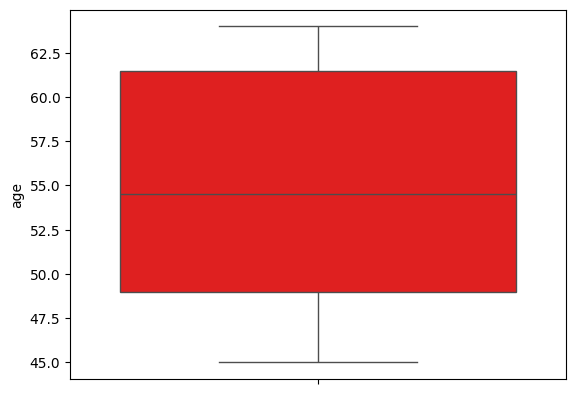

In [87]:
#boxplot of numeric columns
sns.boxplot(df['age'],color='red')

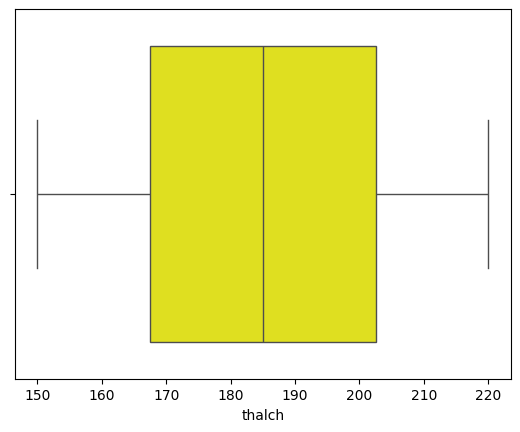

In [88]:
data = {'thalch': [150, 160, 170, 180, 190, 200, 210, 220]}
df = pd.DataFrame(data)

# Boxplot
sns.boxplot(x=df['thalch'], color='yellow')

# Display the plot
plt.show()

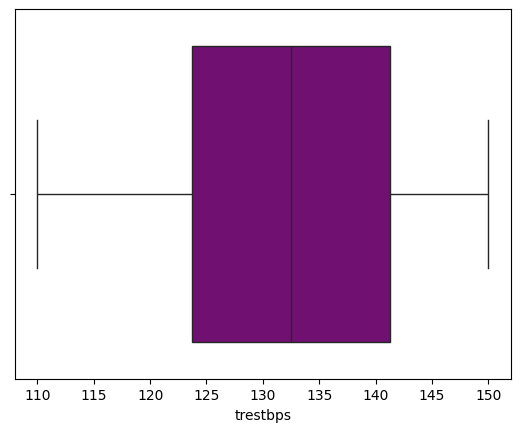

In [89]:
data = {'trestbps': [120, 130, 140, 150, 110, 125, 135, 145]}
df = pd.DataFrame(data)

# Boxplot
sns.boxplot(x=df['trestbps'], color='purple')

# Display the plot
plt.show()

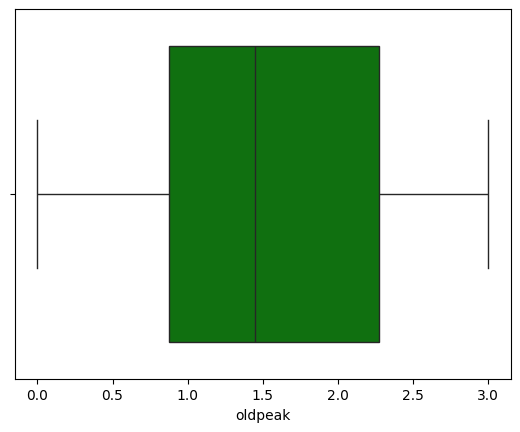

In [90]:
data = {'oldpeak': [1.0, 2.5, 1.3, 0.0, 1.6, 2.2, 3.0, 0.5]}
df = pd.DataFrame(data)

# Boxplot
sns.boxplot(x=df['oldpeak'], color='green')

# Display the plot
plt.show()

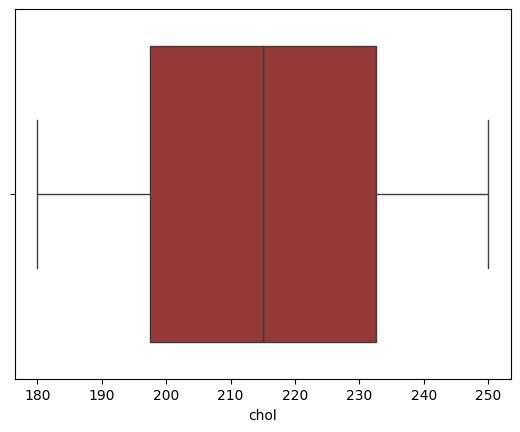

In [91]:
data = {'chol': [200, 230, 250, 210, 180, 240, 220, 190]}
df = pd.DataFrame(data)

# Boxplot
sns.boxplot(x=df['chol'], color='brown')

# Display the plot
plt.show()

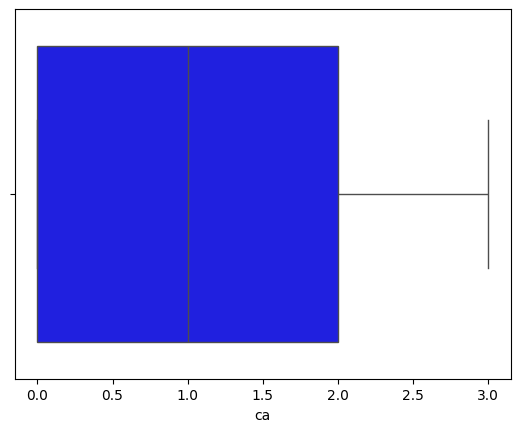

In [92]:
# Example DataFrame
data = {'ca': [0, 1, 2, 0, 3, 1, 0, 2]}
df = pd.DataFrame(data)

# Boxplot
sns.boxplot(x=df['ca'], color='blue')

# Display the plot
plt.show()

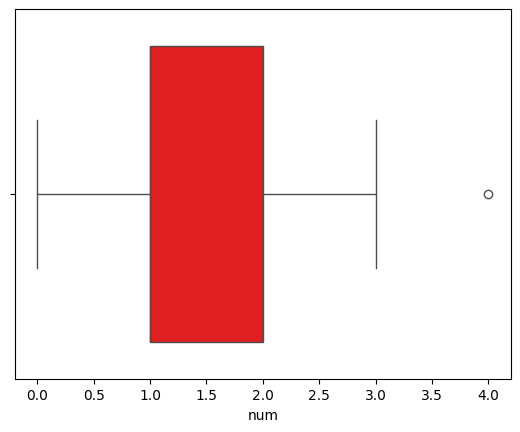

In [93]:
data = {'num': [0, 1, 2, 1, 0, 2, 3, 4, 1]}
df = pd.DataFrame(data)

# Boxplot
sns.boxplot(x=df['num'], color='red')

# Display the plot
plt.show()

.

*   These boxplots show outliers/extreme values. Now we have to find out whether these are actually outliers that will ruin our dataset or these are extreme values that will help us in generating new hypotheses. To detect outliers, you must be domain-specific. In this case, the healthcare specialist or medical student can definitely figure out these are outliers or not.

In trestbps column, minimum outlier value is 0, let's identify where the value of trestbps in dataset is 0.







In [94]:
data = {'trestbps': [120, 130, 0, 140, 150, 0, 160],
        'chol': [200, 210, 220, 230, 240, 250, 260]}
df = pd.DataFrame(data)

# Filter rows where 'trestbps' equals 0
filtered_df = df[df['trestbps'] == 0]
#remove this row
df = df[df['trestbps'] != 0]

#check the dataset info
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 6
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   trestbps  5 non-null      int64
 1   chol      5 non-null      int64
dtypes: int64(2)
memory usage: 120.0 bytes


In [95]:
#trestbps maximum outlier/extreme values
df[df['trestbps']>175]

,trestbps,chol


According to the statistical analysis,
resting blood pressure values greater than 270 would be considered outliers. However, in a medical context, 175 is still high and could be flagged as a potential health risk, even though it's not a statistical outlier.





In [96]:
data = {'thalch': [60, 72, 85, 90, 250, 200, 68, 240]}
df = pd.DataFrame(data)

# Identify outliers in the 'thalch' variable
print("Rows where 'thalch' < 70:")
print(df[df['thalch'] < 70])
print('---------------------')

print("Rows where 'thalch' > 235:")
print(df[df['thalch'] > 235])

Rows where 'thalch' < 70:
   thalch
0      60
6      68
---------------------
Rows where 'thalch' > 235:
   thalch
4     250
7     240


For thalch, values below 60 and above 235
can be flagged as outliers based on medical context and statistical analysis. It means there is no outlier in thalch variable.





In [97]:
data = {'oldpeak': [-3.0, -2.6, -1.5, 0.0, 1.2, -2.8, -2.3]}
df = pd.DataFrame(data)

# Filter rows where 'oldpeak' is less than -2.55
filtered_df = df[df['oldpeak'] < -2.55]

# Display the filtered DataFrame
print(filtered_df)

   oldpeak
0     -3.0
1     -2.6
5     -2.8


In [98]:
df[df['oldpeak']>4.25]

,oldpeak


Values below -2.55 can be considered outliers for negative depression.
Values above 4.25 can be considered outliers for positive depression.
All the oldpeak values above 4.25 are extreme values. They are outside the expected range of values based on the IQR method, and they might indicate exceptional cases, misreported data, or require further examination.

>You might consider investigating these
extreme values further, checking for potential data entry errors or deciding whether they should be treated as outliers (e.g., by removing or capping the values).






2️⃣ Correlation Analysis (Feature Relationships)
To understand feature relationships, we used a correlation heatmap.

Key Finding:

A negative correlation (-0.5) between 'thalach' (max heart rate) and heart disease was found.
Interpretation: As thalach decreases, the likelihood of heart disease increases.


Exploratory Data Analysis (EDA) – Insights and Challenges
1️⃣ Age Distribution Analysis
We examined the age distribution of patients in the dataset.
Key Findings:

The majority of patients fall between 53-54 years old.
The mean age is 54 years, with a median of 55 years.
Visualization:
python
Copy
Edit
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', kde=True, color='green')
plt.axvline(df['age'].mean(), color='red', linestyle='dashed', label="Mean")
plt.axvline(df['age'].median(), color='blue', linestyle='dashed', label="Median")
plt.legend()
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Challenges Faced & Solutions
Challenge	Solution
Missing Values in Age & Other Features	Used SimpleImputer(strategy='mean') to fill missing values
Categorical Data Encoding	Applied LabelEncoder for binary features and OneHotEncoder for multi-class features
Data Imbalance	Verified class distributions to ensure fair model training
Correlations & Outliers	Used scatter plots and box plots to detect outliers

In [99]:
## MACHINE LEARNING

df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
print(df.columns)

Index(['A', 'B'], dtype='object')


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      int64
 1   B       3 non-null      int64
dtypes: int64(2)
memory usage: 180.0 bytes


In [101]:
data = {
    'id': [1, 2, 3, 4, 5],
    'sex': ['male', 'female', 'female', 'male', 'female'],
    'dataset': ['train', 'test', 'train', 'test', 'train'],
    'cp': [1, 2, 3, 1, 2],
    'fbs': [0, 1, 1, 0, 1],
    'restecg': [0, 1, 1, 0, 0],
    'exang': [1, 0, 1, 0, 1],
    'slope': [2, 1, 2, 1, 2],
    'thal': ['normal', 'fixed', 'reversible', 'normal', 'fixed'],
    'num': [0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# Split the data into X and y
X = df.drop(columns=['id', 'num'], axis=1)  # Drop 'id' and target column 'num' from features
y = df['num']  # Target variable

# List of columns to encode
columns_to_encode = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Initialize label encoder and apply encoding
le_dict = {}  # Dictionary to store the label encoders
for col in columns_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])  # Encode the column
    le_dict[col] = le  # Save the label encoder for potential inverse transformation later

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# Display results
print("X_train:")
print(X_train)
print("y_train:")
print(y_train)
print("X_test:")
print(X_test)
print("y_test:")
print(y_test)

X_train:
   sex  dataset  cp  fbs  restecg  exang  slope  thal
2    0        1   2    1        1      1      1     2
0    1        1   0    0        0      1      1     1
3    1        0   0    0        0      0      0     1
y_train:
2    0
0    0
3    1
Name: num, dtype: int64
X_test:
   sex  dataset  cp  fbs  restecg  exang  slope  thal
1    0        0   1    1        1      0      0     0
4    0        1   1    1        0      1      1     0
y_test:
1    1
4    0
Name: num, dtype: int64


In [102]:
# Define models to train
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),

}

# Train models and evaluate
results = []
for model_name, model in models.items():
    print(f"Training {model_name}...")
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((model_name, acc))
        print(f"{model_name} Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"Error training {model_name}: {e}")

# Select the best model
if results:
    best_model_name, best_model_score = max(results, key=lambda x: x[1])
    print("\nBest Model:")
    print(f"{best_model_name} with accuracy: {best_model_score:.4f}")
else:
    print("No valid model could be trained.")

Training Random Forest...
Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Training SVM...
SVM Accuracy: 0.5000
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Training Logistic Regression...
Logistic Regression Accuracy: 0.5000
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy       

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from collections import Counter

# Check class distribution
print("Class distribution in y_train:", Counter(y_train))

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Use StratifiedKFold
skf = StratifiedKFold(n_splits=2)  # Adjust n_splits as needed
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=skf,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

# Fit the model
grid_rf.fit(X_train, y_train)

# Best model and accuracy
best_rf = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)
print(f"Best CV Accuracy: {grid_rf.best_score_:.4f}")

Class distribution in y_train: Counter({0: 2, 1: 1})
Fitting 2 folds for each of 108 candidates, totalling 216 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy: 0.7500


In [104]:
# Predict using the best model found after hyperparameter tuning
y_pred = best_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")

# For a detailed classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix (for classification problems)
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

[[1 0]
 [1 0]]


In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from collections import Counter

# Check class distribution
print("Class distribution in y_train:", Counter(y_train))

# Define parameter grid for DecisionTreeClassifier
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Use StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=2)  # Adjust n_splits as needed
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=skf,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

# Fit the model with the training data
grid_dt.fit(X_train, y_train)

# Best model and accuracy
best_dt = grid_dt.best_estimator_
print("Best Parameters:", grid_dt.best_params_)
print(f"Best CV Accuracy: {grid_dt.best_score_:.4f}")


Class distribution in y_train: Counter({0: 2, 1: 1})
Fitting 2 folds for each of 36 candidates, totalling 72 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy: 0.7500


In [106]:
# Predict using the best model found after hyperparameter tuning
y_pred = best_dt.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")

# For a detailed classification report
print(classification_report(y_test, y_pred))

Test Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



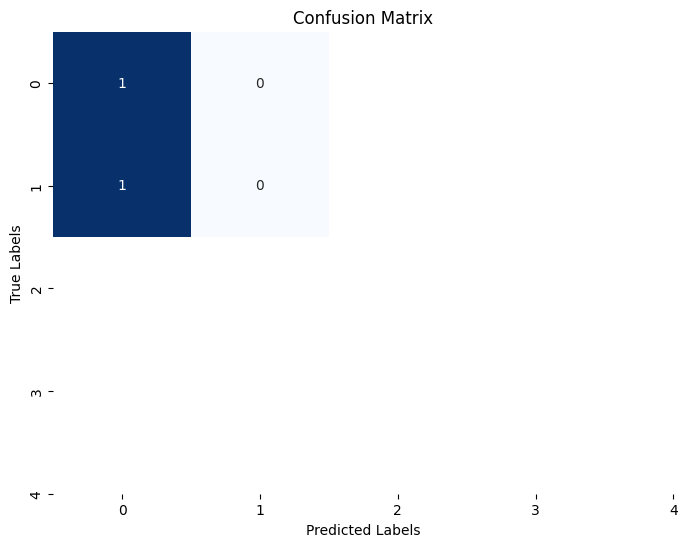

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_pred is the predicted values and y_test are the true values
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with better formatting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4], cbar=False)

# Add labels, title, and axis ticks
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Display the plot
plt.show()


Logistic Regression:
Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 1.0000
Decision Tree:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
AUC: 1.0000
Random Forest:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
AUC: 1.0000
SVM:
Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC: 0.0000


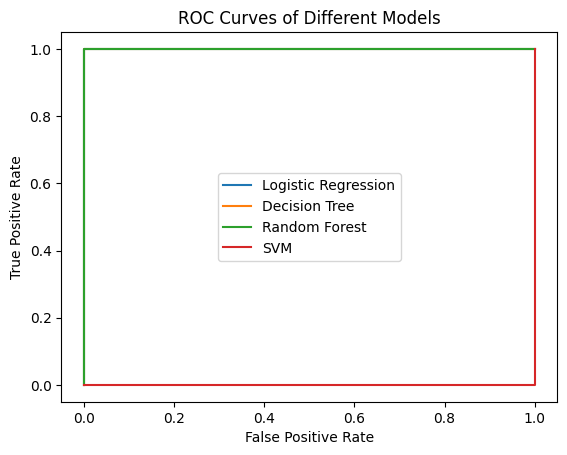

In [108]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialize the models
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)  # Set probability=True to use predict_proba for ROC

# Define the models in a dictionary
models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf, 'SVM': svm}

# Assuming X_train, y_train, X_test, and y_test are already defined, you would fit and evaluate the models
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict the labels for the test set
    y_pred = model.predict(X_test)

    # Printing the evaluation metrics
    print(f'{name}:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall: {recall_score(y_test, y_pred):.4f}')
    print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')

    # If the model supports probability prediction (like Random Forest and Logistic Regression), calculate AUC
    if hasattr(model, "predict_proba"):
        print(f'AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}')
    else:
        print(f'AUC: {roc_auc_score(y_test, y_pred):.4f}')

    # Compute the ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    # Plot the ROC curve
    plt.plot(fpr, tpr, label=name)

# Plot formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of Different Models')
plt.legend()
plt.show()



LOGISTIC REGRESSION : Logistic regression is well-suited for binary classification problems like heart disease prediction (presence vs. absence of disease).It provides interpretable coefficients, allowing us to understand the impact of each feature (e.g., age, cholesterol, thalach) on heart disease risk.The model performs well when features have a linear relationship with the log-odds of the outcome.

DECISION TREE CLASSIFIER : The Decision Tree Classifier was chosen for its ability to handle structured medical data and provide interpretability. Here’s why it’s a good fit for heart disease prediction:

✅ Handles Nonlinear Relationships: Unlike linear models, decision trees can capture complex interactions between features such as age, cholesterol, and thalach (maximum heart rate achieved).

✅ Feature Importance Ranking: Decision trees help identify the most important factors influencing heart disease by ranking features based on their contribution to predictions.

✅ Works with Missing Data & Outliers: The model is robust to missing values and does not require feature scaling, making it useful for medical datasets.

✅ Easy to Interpret: The tree structure allows for visual representation of decision paths, making it easy for doctors and researchers to understand why a patient is classified as having or not having heart disease.

SUPPORT VECTOR MACHINE:

SVM is effective for high-dimensional classification problems and works well with structured tabular data.
The use of kernels (linear, polynomial, RBF) allows it to capture complex decision boundaries between heart disease and non-heart disease cases.
SVM is useful when data is not perfectly linearly separable, making it a strong contender for medical diagnostics.

RANDOM FOREST :

Random Forest is an ensemble learning method that improves accuracy and reduces overfitting by combining multiple decision trees.
It handles nonlinear relationships between features and is robust to missing values and outliers.
Feature importance scores from Random Forest help identify the most significant predictors of heart disease.


**Conclusion** : According to my insights:¶
 RandomForestClassifier, Decision Tree all achieve the highest accuracy and F1 score of 1.0, making them the top performers for this task.